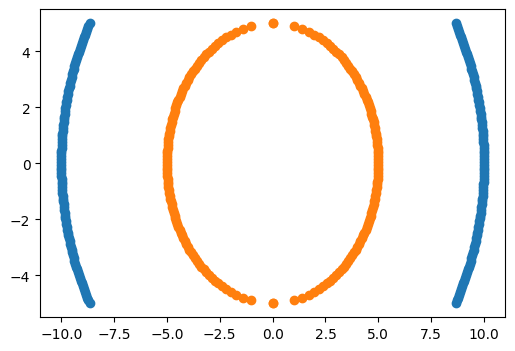

In [98]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.sqrt(10**2 - x**2)
y= np.hstack((y, -y))
x = np.hstack((x, -x))

x1 = np.linspace(-5, 5, 100)
y1 = np.sqrt(5**2 - x1**2)
y1= np.hstack((y1, -y1))
x1 = np.hstack((x1, x1))

plt.figure(figsize=(6, 4))
plt.scatter(y,x)
plt.scatter(y1,x1)

In [99]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1["Y"] = 0 
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns =["X1", "X2"])
df2['Y']= 1
df= pd.concat([df1,df2],axis=0)
df.tail()

,X1,X2,Y
195,-1.969049,4.59596,1
196,-1.714198,4.69697,1
197,-1.406908,4.79798,1
198,-0.999949,4.89899,1
199,-0.000000,5.00000,1


In [100]:
X = df.drop('Y', axis=1)
y = df["Y"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=22)

polynomial kernal

In [101]:
df["X1_squared"] = df["X1"]**2
df["X2_squared"] = df["X2"]**2
df["X1 * X2"] = df["X1"]*df["X2"]
df.head()


,X1,X2,Y,X1_squared,X2_squared,X1 * X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [102]:
X= df.drop("Y", axis=1)
y = df.Y

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=22)

In [103]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [104]:
import plotly.express as px
fig = px.scatter_3d(df, x="X1", y="X2", z="X1 * X2", color="Y")
fig.show()

In [105]:
fig = px.scatter_3d(df, x="X1_squared", y="X2_squared", z="X1 * X2", color="Y")
fig.show()

In [106]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel= "linear")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [107]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel= "poly")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [108]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel= "rbf")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [109]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel= "sigmoid")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

1.0